# Day 5 — Representation Learning & Embeddings

## Note 5.2 — Text embeddings: vectors, similarity and search

### How to read this note

Run the cells from top to bottom, in order. Read each text cell before running the code cell under it.

Most code cells are short. Each one makes one thing, or does one thing, and prints the result. Read the result before you move on.

The **Questions to sit with** blocks are places to stop and think. Try to answer them in your own words.

Every number written in the text of this note came from running this notebook on a CPU. On another machine a few numbers may differ in the last decimal place, and times will differ more.

This note stands alone: it downloads its own data and model, and defines everything it uses.

### Learning goal and outcome

**Goal.** Understand what a text **embedding** is, how we measure whether two embeddings are close, and what embeddings are good and bad at.

**Outcome.** By the end you can turn thousands of sentences into embeddings with a pretrained encoder, explain each step the encoder takes inside, build a similarity search by hand in a few lines of NumPy, score that search fairly against a hand-made baseline, look at the shape of an embedding space, and show at least two ways embeddings get meaning wrong.

### Objectives

By the end of this note you will be able to:

1. Explain why text is harder to represent than a table, and what recurrent networks (RNN, LSTM, GRU) tried and why they were replaced.
2. Build a TF-IDF representation and say what it can and cannot see.
3. Compute dot product, Euclidean distance and cosine similarity by hand, and say when each is the right choice.
4. Load a pretrained sentence encoder and turn sentences into embeddings.
5. Trace the encoder's steps: tokens, token vectors, mean pooling, normalising.
6. Build a similarity search by hand and read its results.
7. Score a representation with nearest-neighbour accuracy and compare two representations fairly.
8. Draw an embedding space in two dimensions and say how such pictures can mislead.
9. Show where embeddings fail: word order, negation, and the lack of a universal "similar enough" threshold.

### Datasets used

**Banking77** (two CSV files, 0.84 MB and 0.24 MB). 13,083 short questions that real customers sent to an online bank, each labelled with one of 77 **intents**. An intent is what the customer wants: `card_arrival`, `lost_or_stolen_card`, `exchange_rate`, and so on. It downloads from PolyAI's public GitHub page with no account.

Why this dataset: the questions are short, so turning them into embeddings is fast on a laptop. Customers say the same thing in many different words ("my card was stolen", "someone took my card"), so you can *see* whether a representation understands meaning. And the 77 labels let us *score* similarity search instead of just looking at it.

**all-MiniLM-L6-v2** (90.9 MB). A small pretrained text encoder, explained in Section 6.

### Table of contents

1. Text has no pixels
2. The sequence problem: what RNNs, LSTMs and GRUs tried
3. Meet Banking77
4. A hand-made text representation: TF-IDF
5. Measuring closeness by hand
6. Loading a pretrained encoder
7. Opening the box: what the encoder does inside
8. Embedding the whole dataset
9. Similarity search, by hand
10. Scoring the search
11. Looking at the embedding space
12. Where embeddings fail
13. What to take away

### Runtime budget

Times are for a laptop CPU. Downloads depend on your internet speed.

| Part | What happens | Time |
|---|---|---|
| Setup | imports, version check | under 1 minute |
| Sections 3–5 | download Banking77 (1 MB), TF-IDF, closeness by hand | under 1 minute |
| Sections 6–7 | download MiniLM (91 MB), look inside it | 1–2 minutes |
| Section 8 | embed 13,083 questions | about 1 minute |
| Sections 9–10 | search and scoring, including logistic regression checks | 1–3 minutes |
| Sections 11–12 | PCA, t-SNE (twice), failure tests | 1–2 minutes |
| Whole note | | about 8 minutes of running, plus reading |

### Environment setup

To install exactly the versions this note was built with, remove the `#` at the start of the `%pip` line, run the cell once, then restart the kernel.

`sentence-transformers` is new today. It is a library for turning sentences into embeddings, and it uses `transformers` underneath. Both are explained when we first use them.

In [1]:
# Remove the "#" on the next line to install the pinned versions, then restart the kernel.
# %pip install torch==2.14.0 transformers==5.18.0 sentence-transformers==6.1.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 matplotlib==3.10.8 scipy==1.17.1

In [2]:
import importlib.metadata as md

PINNED = {"torch": "2.14.0", "transformers": "5.18.0", "sentence-transformers": "6.1.0",
          "scikit-learn": "1.8.0", "numpy": "2.4.4", "pandas": "3.0.2",
          "matplotlib": "3.10.8", "scipy": "1.17.1"}

for package, wanted in PINNED.items():
    installed = md.version(package)
    status = "ok" if installed.split("+")[0] == wanted else "DIFFERENT"
    print(f"{package:22} pinned {wanted:8} installed {installed:12} {status}")

torch                  pinned 2.14.0   installed 2.14.0+cpu   ok
transformers           pinned 5.18.0   installed 5.18.0       ok
sentence-transformers  pinned 6.1.0    installed 6.1.0        ok
scikit-learn           pinned 1.8.0    installed 1.8.0        ok
numpy                  pinned 2.4.4    installed 2.4.4        ok
pandas                 pinned 3.0.2    installed 3.0.2        ok
matplotlib             pinned 3.10.8   installed 3.10.8       ok
scipy                  pinned 1.17.1   installed 1.17.1       ok


### Environment detection

PyTorch can run on `cuda` (an NVIDIA graphics card), `mps` (an Apple Silicon Mac's graphics part) or `cpu`. This cell finds which ones you have, and then the note uses the **CPU on purpose**, so your numbers match the ones written here.

In [3]:
import torch

if torch.cuda.is_available():
    FOUND = "cuda"
elif torch.backends.mps.is_available():
    FOUND = "mps"
else:
    FOUND = "cpu"

DEVICE = "cpu"   # chosen on purpose, so numbers match this note
print("Best hardware found on this machine:", FOUND)
print("Hardware this note will use:        ", DEVICE)
print("CPU threads PyTorch can use:        ", torch.get_num_threads())

Best hardware found on this machine: cpu
Hardware this note will use:         cpu
CPU threads PyTorch can use:         1


In [4]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
print("Data will be saved in:", DATA_DIR.resolve())

Data will be saved in: /home/claude/day5/run_clean/data


## 1. Text has no pixels

In note 5.1 we worked with photos. A photo, however messy, is a fixed grid of numbers: every 224 × 224 photo has exactly 150,528 values, and pixel number 1,000 always means "this colour, at this place".

Text is different in three ways:

- **It is made of symbols, not numbers.** The word "card" is not a number. We have to decide how to turn it into one.
- **It has no fixed length.** "Card stolen" is two words. Some customer messages are seventy.
- **Order and context change the meaning.** "The dog bit the man" and "the man bit the dog" use the same words. "I want to cancel" and "I do not want to cancel" differ by one word and mean the opposite.

A good text representation must turn a sentence of any length into a fixed-length list of numbers, and that list must keep the meaning. Day 4's gradient boosting cannot even start until someone does this.

> **Questions to sit with**
>
> 1. If you had to describe a customer message to a model with a fixed number of columns, what would the columns be?
> 2. "Bank" in "river bank" and "bank account" is one word with two meanings. How could a representation tell them apart?

## 2. The sequence problem: what RNNs, LSTMs and GRUs tried

This section is short and has no code. It is here so you know what came before the models you will use, and why it was replaced.

A **sequence** is data where order matters: words in a sentence, notes in a song, readings over time.

For many years the main tool for sequences was the **recurrent neural network**, or **RNN**. "Recurrent" means "happening again and again". An RNN reads a sentence one word at a time, from left to right. It keeps a list of numbers called the **hidden state**: a running summary of everything it has read so far. At each word, it mixes the new word with the old summary to make a new summary.

```
   "my"        "card"        "was"        "stolen"
     │            │             │              │
     ▼            ▼             ▼              ▼
 [h0] ──▶ RNN ──▶ [h1] ──▶ RNN ──▶ [h2] ──▶ RNN ──▶ [h3] ──▶ RNN ──▶ [h4]  ← summary of the
 (empty)                                                                  whole sentence
```

The last hidden state, `h4`, is the representation of the whole sentence.

This works, but it has three problems:

1. **Everything squeezed into one fixed list.** However long the text, the whole meaning must fit into one hidden state of fixed size. Long texts lose detail.
2. **Forgetting.** To learn that the first word mattered for the last, the gradient (Day 1) must travel back through every step. On Day 3 (note 3.3) you saw gradients shrink as they pass through many layers. Here every word is one more step, so the start of a long text fades. This is the *vanishing gradient* problem again.
3. **Slow.** Word 4 cannot be processed until word 3 is done. Graphics cards are fast because they do many things at the same time, and an RNN does not let them.

The **LSTM** (*long short-term memory*) and the **GRU** (*gated recurrent unit*) were improved RNNs. They added **gates**: small learned switches that decide, at each word, what to keep in the summary, what to forget, and what to add. Gates helped a lot with forgetting, and LSTMs powered translation and speech systems for years. But they kept problem 1 and problem 3.

The idea that replaced them is **attention**: instead of passing one summary from word to word, let every word look directly at every other word, all at the same time. No long chain to forget along, and everything can run in parallel. Attention is the whole subject of Day 6. The encoder we use in this note is already built on it.

<div align="center">

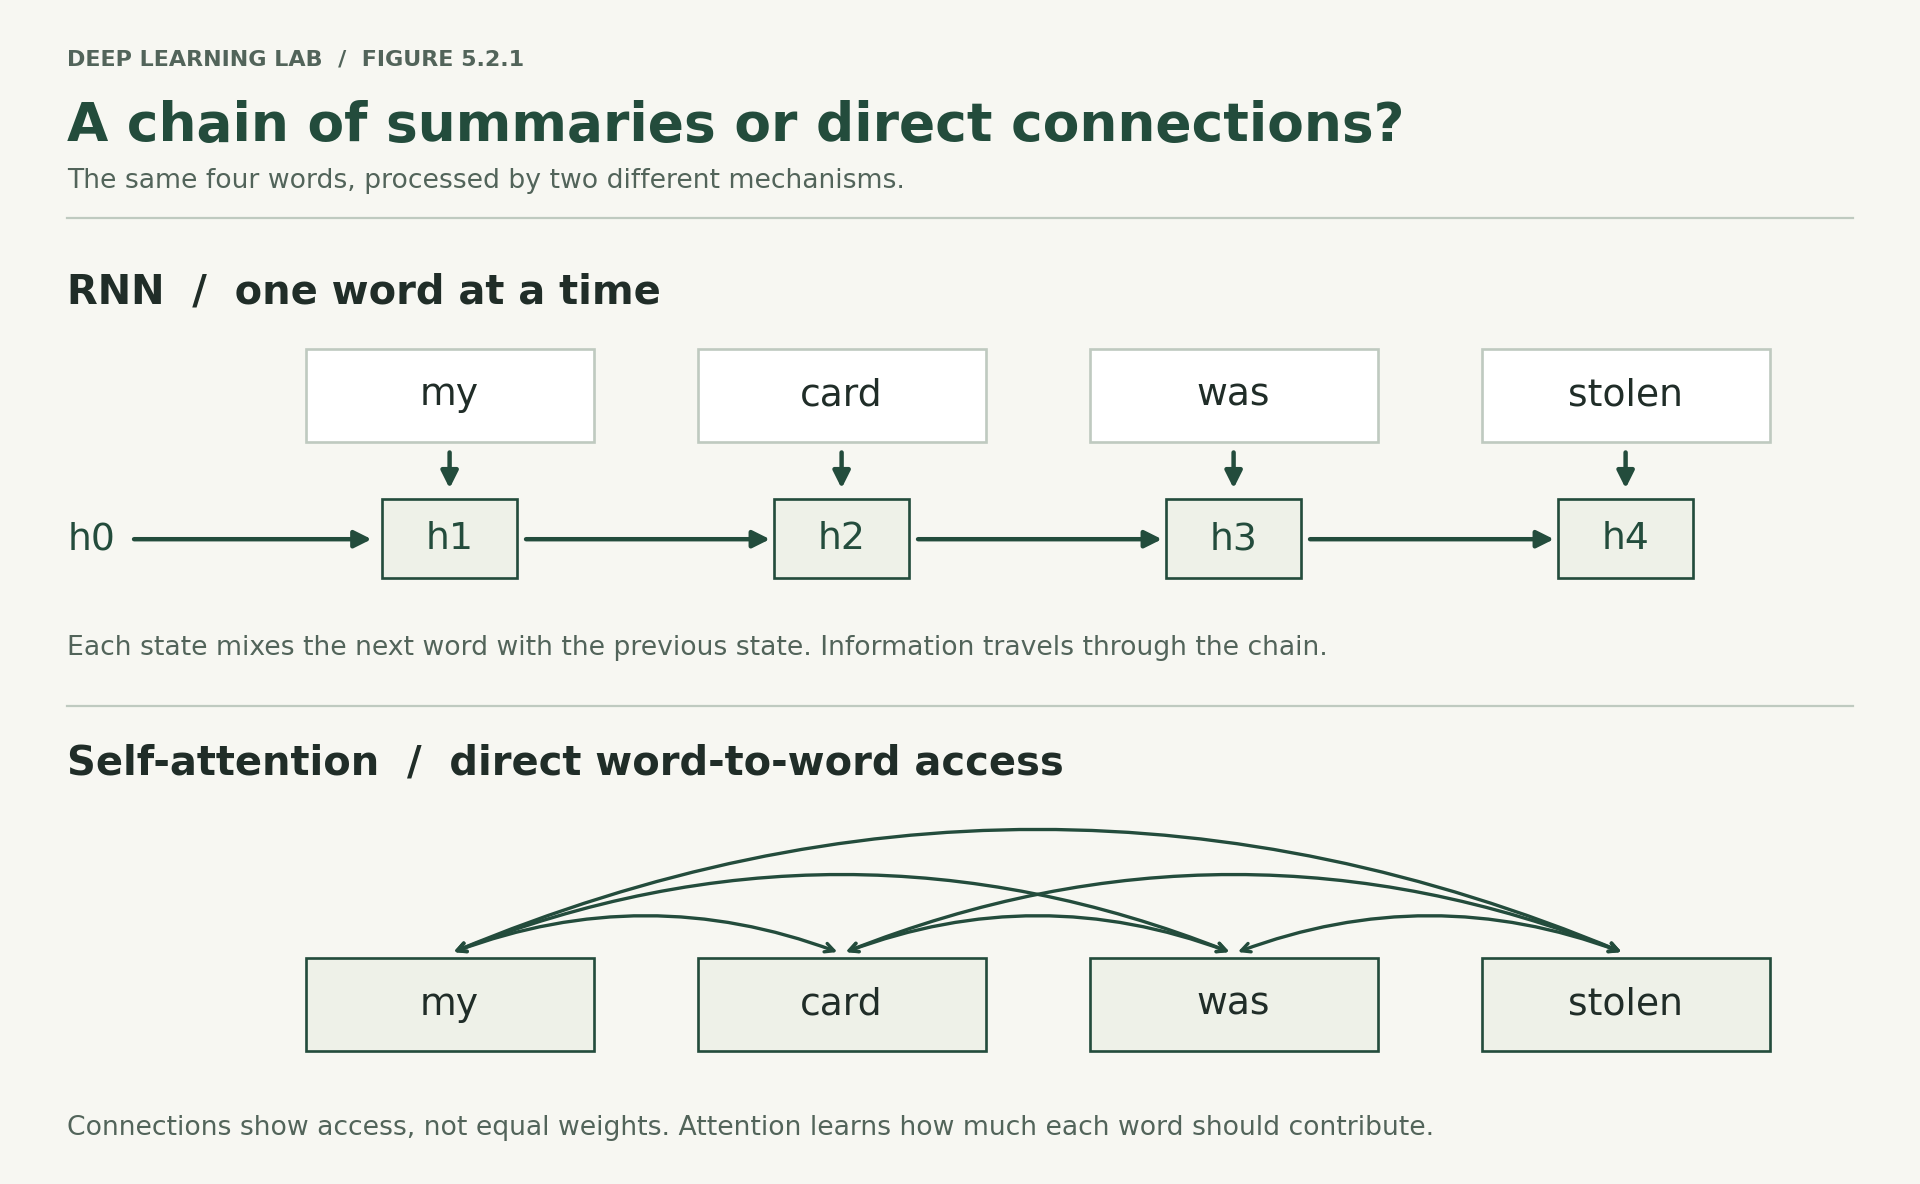

<p><b>Figure 5.2.1.</b> RNN states pass a running summary along a sequence. Unmasked self-attention gives tokens direct access to each other; learned weights need not be equal.</p>

</div>

> **Questions to sit with**
>
> 1. In the sentence "The card that I ordered from your app three weeks ago, before I moved house, has still not arrived", which early words does the end of the sentence depend on?
> 2. Why would processing words one at a time be a problem when training on billions of sentences?

## 3. Meet Banking77

`pd.read_csv(url)` can read a CSV file straight from a web address. We then save a copy with `.to_csv(path, index=False)` (`index=False` means "do not write the row numbers as an extra column"), so the next run reads from disk instead.

In [5]:
BANKING_URL = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/{split}.csv"

def load_banking(split):
    path = DATA_DIR / f"banking77_{split}.csv"
    if not path.exists():
        pd.read_csv(BANKING_URL.format(split=split)).to_csv(path, index=False)
    return pd.read_csv(path)

train = load_banking("train")
test = load_banking("test")
print("train:", train.shape, "  test:", test.shape)
print("columns:", list(train.columns))

train: (10003, 2)   test: (3080, 2)
columns: ['text', 'category']


In [6]:
train.head(8)

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
5,When did you send me my new card?,card_arrival
6,Do you have info about the card on delivery?,card_arrival
7,What do I do if I still have not received my n...,card_arrival


Each row is one customer question (`text`) and its intent (`category`). Let us count the intents and see how many questions each has.

`.nunique()` counts distinct values. `.value_counts()` counts how often each value appears.

In [7]:
counts = train["category"].value_counts()
print("Number of intents:", train["category"].nunique())
print("Questions per intent: fewest", counts.min(), " most", counts.max(), " middle", int(counts.median()))

Number of intents: 77
Questions per intent: fewest 35  most 187  middle 127


How long are the questions? `.str.split()` cuts each text into words at the spaces, and `.str.len()` counts the pieces.

In [8]:
words = train["text"].str.split().str.len()
print("Words per question: shortest", words.min(), " average", round(words.mean(), 1), " longest", words.max())

Words per question: shortest 2  average 11.9  longest 79


Now read some questions from two intents that sound alike. Telling them apart needs meaning, not just matching words.

In [9]:
for intent in ["card_arrival", "card_delivery_estimate"]:
    print(f"--- {intent} ---")
    for t in train.loc[train["category"] == intent, "text"].head(4):
        print("  ", t)

--- card_arrival ---
   I am still waiting on my card?
   What can I do if my card still hasn't arrived after 2 weeks?
   I have been waiting over a week. Is the card still coming?
   Can I track my card while it is in the process of delivery?
--- card_delivery_estimate ---
   Can it specifically be delivered on a certain date?
   I need to get my card quickly
   When can I expect my card? I live in the US.
   Help! When will the card arrive at my home?


`card_arrival` is "where is my card?". `card_delivery_estimate` is "how long will it take?". Both use the words *card* and *arrive*. Keep these two in mind.

We will use the **train** questions as the collection we search through (10,003 questions) and the **test** questions as new questions coming in (3,080).

## 4. A hand-made text representation: TF-IDF

Before learned encoders, the standard way to turn text into numbers was to count words. The most common version is called **TF-IDF**.

- **TF** means *term frequency*: how often a word appears in this question.
- **IDF** means *inverse document frequency*: a weight that is **large for rare words** and **small for common words**. "the" appears in thousands of questions, so it tells us little. "nicked" appears in very few, so when it appears it tells us a lot.
- **TF-IDF** multiplies the two. Each question becomes a list with one number for every word in the vocabulary. The **vocabulary** is the list of all distinct words seen in the training questions.

In scikit-learn, `TfidfVectorizer()` does all of this. `.fit(texts)` learns the vocabulary and the IDF weights from the training texts only (the Day 4 rule again). `.transform(texts)` turns texts into TF-IDF lists.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf.fit(train["text"])
vocabulary = tfidf.get_feature_names_out()
print("Vocabulary size:", len(vocabulary))
print("A few words from it:", list(vocabulary[2000:2008]))

Vocabulary size: 2320
A few words from it: ['these', 'they', 'thief', 'thin', 'thing', 'things', 'think', 'thinking']


Let us turn one question into TF-IDF and look at it.

In [11]:
one = tfidf.transform(["my card was stolen"])
print("Shape:", one.shape)
print("How many numbers are not zero:", one.nnz)

Shape: (1, 2320)
How many numbers are not zero: 4


The list has one number for every vocabulary word, but only 4 are not zero: one for each word in the question. A list where almost every value is zero is called **sparse**. scikit-learn stores only the non-zero values, to save memory.

Let us see which words got which weights. `.nonzero()` returns the positions of the non-zero values, and we look up each position in the vocabulary.

In [12]:
rows, cols = one.nonzero()
for c in cols:
    print(f"{vocabulary[c]:10} weight {one[0, c]:.3f}")

card       weight 0.329
my         weight 0.235
stolen     weight 0.790
was        weight 0.462


Common words like "my" and "was" get small weights. Rarer, more meaningful words get bigger ones.

Now the big weakness. TF-IDF counts words. It does not see their order.

In [13]:
a = tfidf.transform(["the dog bit the man"]).toarray()
b = tfidf.transform(["the man bit the dog"]).toarray()
print("Are the two TF-IDF lists exactly the same?", np.allclose(a, b))

Are the two TF-IDF lists exactly the same? True


To TF-IDF these two sentences are *identical*. It also has no idea that "stolen" and "took" are related, because they are different words. Each word is its own column, with no link to any other.

> **Questions to sit with**
>
> 1. A customer writes "my card got nicked". If no training question contains "nicked", what will TF-IDF do with that word?
> 2. TF-IDF is cheap, fast, and needs no neural network. When might it be all you need?

## 5. Measuring closeness by hand

Before we use embeddings, we need to be clear about how to say two lists of numbers are "close". There are three common measures. We will compute each by hand on tiny lists of three numbers, so you can see every step.

In [14]:
a = np.array([1.0, 2.0, 0.0])
b = np.array([2.0, 4.0, 0.0])   # b points the same way as a, but is twice as long
c = np.array([0.0, 1.0, 2.0])   # c points a different way

### Dot product

The **dot product** multiplies matching positions and adds them up: `a · b = a₁b₁ + a₂b₂ + a₃b₃`. In NumPy you write `a @ b`.

In [15]:
print("by hand:", 1*2 + 2*4 + 0*0)
print("a @ b =", a @ b)
print("a @ c =", a @ c)

by hand: 10
a @ b = 10.0
a @ c = 2.0


### Length and Euclidean distance

The **length** of a list (also called its **norm**) is the square root of the sum of its squared values: how far the point is from zero. `np.linalg.norm(a)` computes it.

The **Euclidean distance** between two lists is the length of their difference: the straight-line distance between the two points. It is what kNN used in note 5.1.

In [16]:
print("length of a:", round(np.linalg.norm(a), 4))
print("length of b:", round(np.linalg.norm(b), 4))
print("distance a to b:", round(np.linalg.norm(a - b), 4))
print("distance a to c:", round(np.linalg.norm(a - c), 4))

length of a: 2.2361
length of b: 4.4721
distance a to b: 2.2361
distance a to c: 2.4495


### Cosine similarity

**Cosine similarity** asks only one question: *do the two lists point in the same direction?* It ignores how long they are.

It is the dot product divided by both lengths:

cosine(a, b) = (a · b) / (length of a × length of b)

It always lies between −1 and 1. A value of **1** means "exactly the same direction", **0** means "unrelated directions" (at right angles), and **−1** means "opposite directions".

In [17]:
def cosine(x, y):
    return (x @ y) / (np.linalg.norm(x) * np.linalg.norm(y))

print("cosine(a, b) =", round(cosine(a, b), 4))
print("cosine(a, c) =", round(cosine(a, c), 4))

cosine(a, b) = 1.0
cosine(a, c) = 0.4


`b` is twice as long as `a`, so Euclidean distance says they are 2.2361 apart. But they point exactly the same way, so cosine says 1.0, a perfect match. For meaning, direction is usually what we care about, which is why cosine is the standard measure for embeddings.

### The shortcut: unit vectors

A list with length exactly 1 is called a **unit vector**. Turning a list into a unit vector (dividing it by its own length) is called **normalising**.

If both lists are unit vectors, the division in the cosine formula is dividing by 1 × 1. So **for unit vectors, cosine similarity is just the dot product.** That makes search very fast, as you will see in Section 9.

In [18]:
a_unit = a / np.linalg.norm(a)
b_unit = b / np.linalg.norm(b)
print("length of a_unit:", round(np.linalg.norm(a_unit), 4))
print("a_unit and b_unit are the same list:", np.allclose(a_unit, b_unit))
print("dot product of unit vectors:", round(a_unit @ b_unit, 4), " cosine:", round(cosine(a, b), 4))

length of a_unit: 1.0
a_unit and b_unit are the same list: True
dot product of unit vectors: 1.0  cosine: 1.0


Normalising `a` and `b` makes them the same list, because they only ever differed in length.

<div align="center">

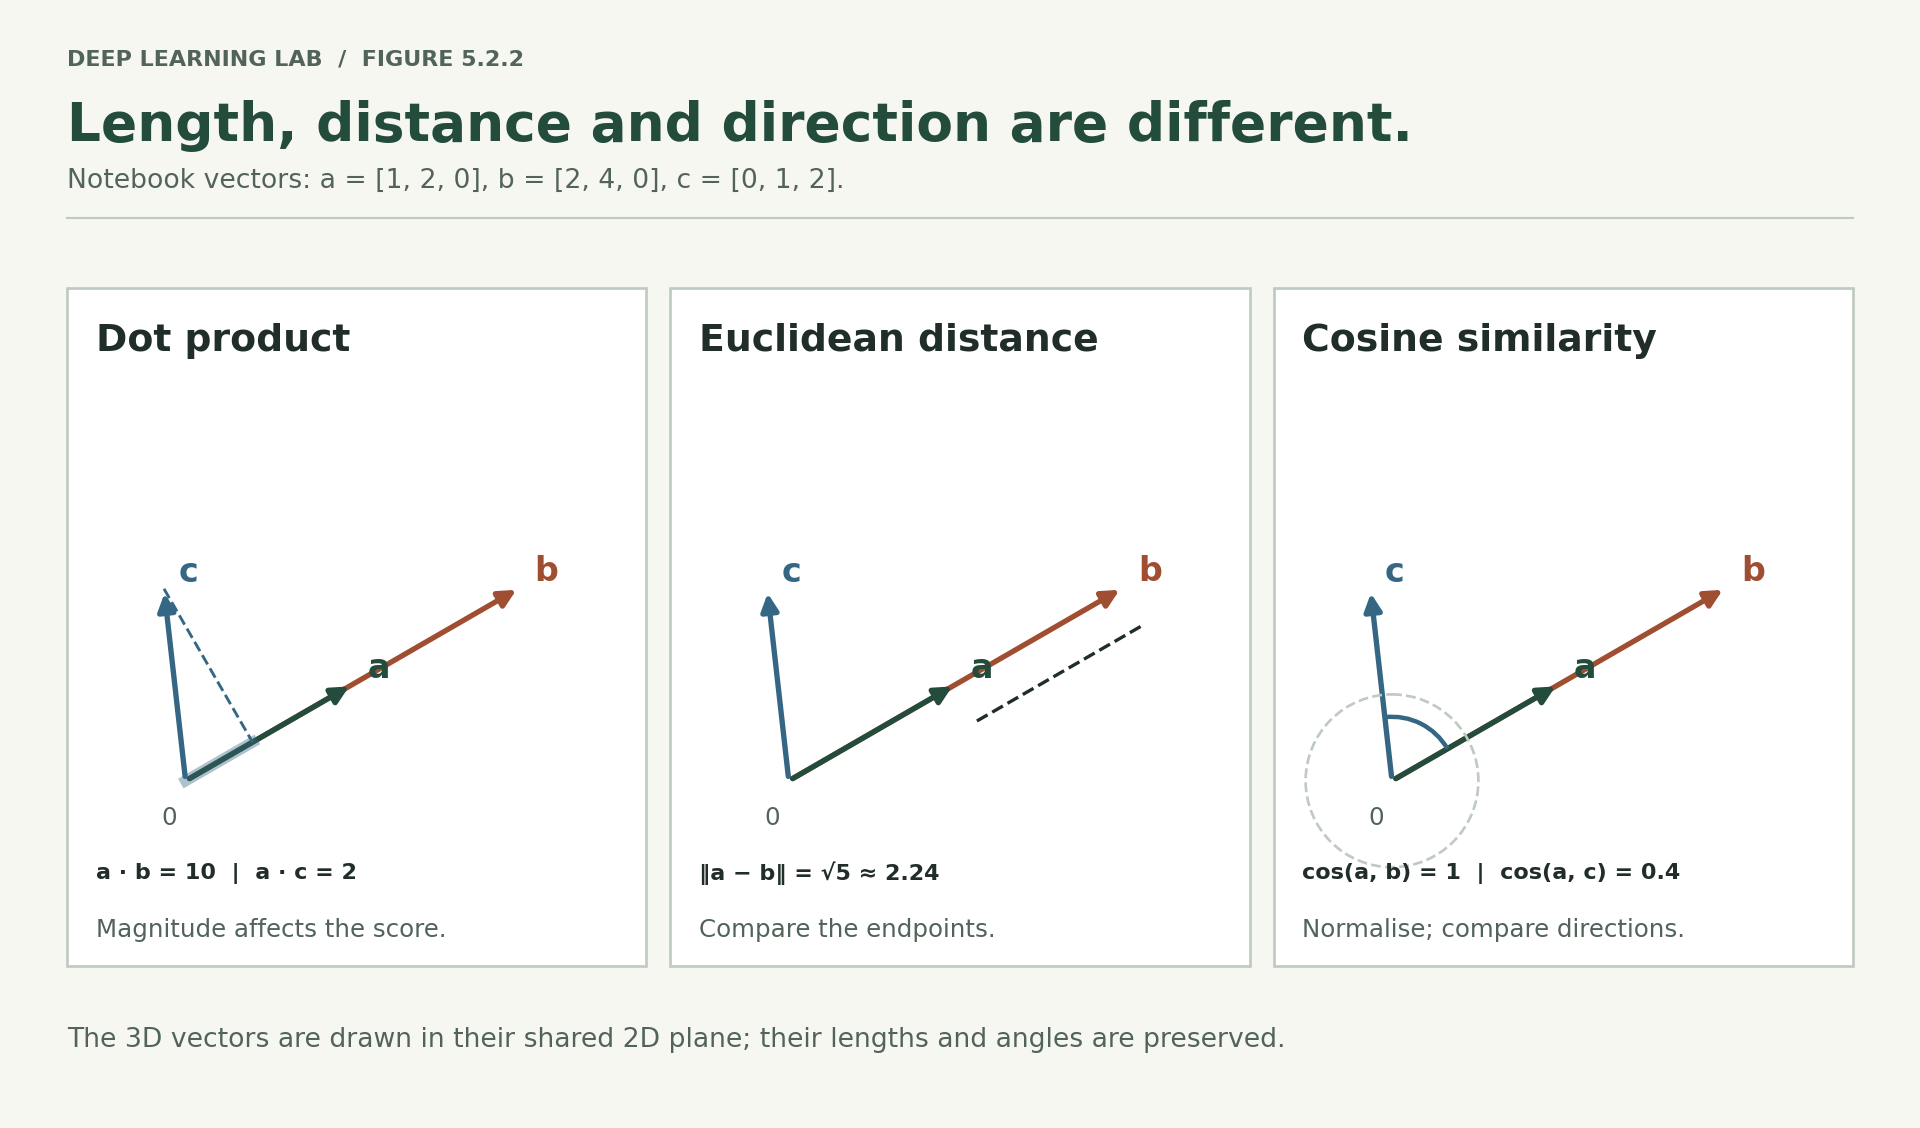

<p><b>Figure 5.2.2.</b> The lesson’s three-dimensional vectors drawn in the plane they span. Doubling a vector changes dot product and distance but preserves cosine similarity.</p>

</div>

## 6. Loading a pretrained encoder

An **embedding** is a representation made by a learned encoder: a fixed-length list of numbers, where things with similar meaning get lists that point in similar directions. The list is often called a **vector**, which is the maths word for a list of numbers.

We will not train an encoder today. We will use one that someone else trained on a very large amount of text. (Note 5.3 explains how it was trained.)

### The Hugging Face Hub, briefly

The **Hugging Face Hub** is a website where people share trained models. Each model has a name like `sentence-transformers/all-MiniLM-L6-v2`. When code asks for that name, the library downloads the model's files from the Hub the first time and saves them on your computer (in a folder called the *cache*), so the next time it loads from disk. No account is needed for public models. Day 7 is the full tour of Hugging Face; today we only download one model by name.

You may see a warning that you are "sending unauthenticated requests to the HF Hub". It only means you are not logged in. Downloads still work; they may just be a little slower.

### The model: all-MiniLM-L6-v2

- **MiniLM** is the name of a small Transformer, the kind of network Day 6 takes apart.
- **L6** means it has 6 layers.
- **all** and **v2** are the name its makers gave this trained version.

`SentenceTransformer(name, device="cpu")` downloads (if needed) and loads it.

In [19]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)
print(encoder)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14918.62it/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)


Printing the encoder shows it is three steps in a row. We will open each one in Section 7:

- `(0) Transformer`: turns the words into one vector per word piece.
- `(1) Pooling` with `pooling_mode: mean`: averages those vectors into one vector for the whole sentence.
- `(2) Normalize`: makes that vector a unit vector (length 1).

A few facts about it:

In [20]:
n_weights = sum(p.numel() for p in encoder.parameters())
print(f"Weights:                  {n_weights:,}")
print("Embedding size:          ", encoder.get_embedding_dimension())
print("Longest input (pieces):  ", encoder.max_seq_length)

Weights:                  22,713,216
Embedding size:           384
Longest input (pieces):   256


22.7 million weights (compare: our Day 3 network had 5,377). Every sentence becomes **384** numbers. Inputs longer than 256 word pieces are cut off, which is never a problem for short bank questions.

### Turning one sentence into an embedding

`encoder.encode(sentences, ...)` is the method that does all three steps. The arguments we use:

- `sentences`: a list of texts.
- `batch_size`: how many texts to push through at once (Day 2's batches).
- `normalize_embeddings=True`: make each vector length 1, so cosine is a plain dot product.
- `show_progress_bar=False`: do not print a progress bar.

It returns a NumPy array with one row per sentence.

In [21]:
emb = encoder.encode(["my card was stolen"], batch_size=64,
                     normalize_embeddings=True, show_progress_bar=False)
print("Shape:", emb.shape)
print("First 8 numbers:", np.round(emb[0, :8], 4))
print("Length:", round(float(np.linalg.norm(emb[0])), 4))

Shape: (1, 384)
First 8 numbers: [-0.0849  0.0736  0.0287  0.0075  0.0296  0.0178  0.0729  0.0239]
Length: 1.0


384 numbers, length 1. On their own, the numbers mean nothing to a person. No single number is "the stolen-ness number". Only the **direction** of the whole vector, compared with other vectors, carries meaning. Let us compare.

In [22]:
sentences = ["my card was stolen", "someone took my card", "my card arrived today"]
E = encoder.encode(sentences, normalize_embeddings=True, show_progress_bar=False)
for i in range(3):
    for j in range(i + 1, 3):
        print(f"{E[i] @ E[j]:.3f}   {sentences[i]!r}  vs  {sentences[j]!r}")

0.764   'my card was stolen'  vs  'someone took my card'
0.678   'my card was stolen'  vs  'my card arrived today'
0.705   'someone took my card'  vs  'my card arrived today'


The two sentences about theft, which share only the words "my card", score **0.764**. "Stolen" and "arrived today" score **0.678**. The right pair is on top, which is what we want, and TF-IDF (Section 4) could never have done it: "stolen" and "took" are different words, so it has nothing to connect them.

But look at how *close* the numbers are. A stolen card and a card that arrived safely, opposite situations for a bank, still score 0.678. Cosine scores from this model are not percentages of "sameness". Only their order is meaningful. Section 12 comes back to this.

## 7. Opening the box: what the encoder does inside

`encode` did three steps in one call. Let us do them one by one, so nothing is hidden. You will see each step again, in much more detail, on Day 6.

### Step 1 — the tokenizer cuts text into pieces

A **tokenizer** cuts text into **tokens**: whole words, or pieces of words for rare words. Each token has an ID number in a fixed list. `encoder.tokenizer(text, return_tensors="pt")` does this and returns PyTorch tensors (`"pt"` means PyTorch).

In [23]:
tokens = encoder.tokenizer("my card was stolen", return_tensors="pt")
print("Keys:", list(tokens.keys()))
print("input_ids:     ", tokens["input_ids"])
print("attention_mask:", tokens["attention_mask"])

Keys: ['input_ids', 'token_type_ids', 'attention_mask']
input_ids:      tensor([[ 101, 2026, 4003, 2001, 7376,  102]])
attention_mask: tensor([[1, 1, 1, 1, 1, 1]])


- `input_ids` are the token ID numbers.
- `attention_mask` has a 1 for every real token. When many sentences of different lengths are put in one batch, the short ones are filled up with padding, which gets a 0 here so it can be ignored.
- `token_type_ids` is only used when two sentences are fed in together; you can ignore it.

`convert_ids_to_tokens` turns IDs back into the pieces.

In [24]:
print(encoder.tokenizer.convert_ids_to_tokens(tokens["input_ids"][0]))

['[CLS]', 'my', 'card', 'was', 'stolen', '[SEP]']


Four words became six tokens. `[CLS]` and `[SEP]` are special markers the model always adds at the start and end. Now a word the model probably sees less often:

In [25]:
print(encoder.tokenizer.convert_ids_to_tokens(encoder.tokenizer("my card got nicked")["input_ids"]))

['[CLS]', 'my', 'card', 'got', 'nick', '##ed', '[SEP]']


"nicked" (British slang for "stolen") is not in the tokenizer's list of whole words, so it is cut into `nick` and `##ed`. The `##` means "this piece continues the word before it". Cutting rare words into known pieces is how the model can accept *any* text without ever meeting an unknown word. Whether it *understands* the pieces is a different question, and Section 9 tests it.

### Step 2 — the Transformer gives every token a vector

`encoder[0]` is the first step, and `encoder[0].auto_model` is the Transformer network inside it. We give it the tokens. Its output called `last_hidden_state` has shape `(sentences, tokens, 384)`: **one 384-number vector for every token**.

These are not fixed word vectors. Each token's vector depends on the words around it. That is what attention does, and it is Day 6's subject.

In [26]:
transformer = encoder[0].auto_model
with torch.no_grad():
    out = transformer(**tokens)
token_vectors = out.last_hidden_state
print("Shape:", tuple(token_vectors.shape))

Shape: (1, 6, 384)


`transformer(**tokens)` passes each entry of the `tokens` dictionary as a named argument: `input_ids=...`, `attention_mask=...` and so on. `torch.no_grad()` turns off gradient tracking, as in note 5.1, because we are not training.

### Step 3 — mean pooling turns many vectors into one

**Pooling** means combining many vectors into one. **Mean pooling** takes the average. We only average real tokens, so we multiply by the attention mask (padding becomes zero) and divide by the number of real tokens.

`mask[..., None]` adds a last dimension so the mask's shape `(1, 6, 1)` lines up with the vectors' shape `(1, 6, 384)`. This is broadcasting, from Day 2.

In [27]:
mask = tokens["attention_mask"].float()
summed = (token_vectors * mask[..., None]).sum(dim=1)
count = mask.sum(dim=1, keepdim=True)
sentence_vector = summed / count
print("Shape after mean pooling:", tuple(sentence_vector.shape))

Shape after mean pooling: (1, 384)


### Step 4 — normalise to length 1

In [28]:
sentence_vector = sentence_vector / sentence_vector.norm(dim=1, keepdim=True)
print("Length:", round(sentence_vector.norm().item(), 4))

Length: 1.0


### Did we rebuild `encode` correctly?

If our four steps are the same as `encode`, the two vectors should match. The largest absolute difference between them tells us.

In [29]:
by_hand = sentence_vector[0].numpy()
by_encode = encoder.encode(["my card was stolen"], normalize_embeddings=True, show_progress_bar=False)[0]
print("Largest difference:", float(np.abs(by_hand - by_encode).max()))

Largest difference: 0.0


The largest difference is **0.0**: our four steps give exactly the same numbers as `encode`. So a sentence embedding from this model really is just **the average of its token vectors, made length 1**. Everything clever happens inside the Transformer, in Step 2.

```
 "my card was stolen"
        │  tokenizer
        ▼
 [CLS] my card was stolen [SEP]          6 tokens
        │  Transformer (6 layers, attention: Day 6)
        ▼
 6 vectors × 384 numbers                 one vector per token, each aware of its neighbours
        │  mean pooling
        ▼
 1 vector × 384 numbers
        │  normalise
        ▼
 1 unit vector × 384 numbers  =  the embedding
```

## 8. Embedding the whole dataset

Now we embed all 13,083 questions. `time.perf_counter()` reads a clock, so the difference between two readings is how long the code between them took.

Because embedding takes about a minute on a CPU, we save the result to a file with `np.save` and load it with `np.load` if the file is already there. The saved file is exactly what `encode` returns; nothing about the result changes.

In [30]:
def embed_split(name, texts):
    path = DATA_DIR / f"banking77_{name}_minilm.npy"
    if path.exists():
        return np.load(path)
    start = time.perf_counter()
    vectors = encoder.encode(list(texts), batch_size=64,
                             normalize_embeddings=True, show_progress_bar=False)
    print(f"Embedded {len(texts):,} {name} questions in {time.perf_counter() - start:.1f} s")
    np.save(path, vectors)
    return vectors

E_train = embed_split("train", train["text"])
E_test = embed_split("test", test["text"])
print("E_train:", E_train.shape, " E_test:", E_test.shape)

Embedded 10,003 train questions in 62.7 s


Embedded 3,080 test questions in 18.3 s
E_train: (10003, 384)  E_test: (3080, 384)


How much memory? Same rule as Day 4: values × bytes per value.

In [31]:
print(f"E_train: {E_train.size:,} values x {E_train.itemsize} bytes = {E_train.nbytes / 1e6:.1f} MB")

E_train: 3,841,152 values x 4 bytes = 15.4 MB


Compare with note 5.1: one small photo was 150,528 numbers. A whole question is 384 numbers, and the entire 10,003-question collection fits in about 15 MB.

## 9. Similarity search, by hand

A **similarity search** answers: *which stored items are most similar to this new one?* With unit vectors, it takes three steps:

1. Embed the new question (the **query**).
2. Compute its dot product with every stored embedding. Because they are all unit vectors, each dot product is a cosine similarity. `E_train @ q` does all 10,003 at once.
3. Sort the scores from highest to lowest and keep the top *k*. `np.argsort(scores)` gives the positions that would sort the scores from lowest to highest, so we sort `-scores` to get highest first.

In [32]:
q = encoder.encode(["my card got nicked"], normalize_embeddings=True, show_progress_bar=False)[0]
scores = E_train @ q
print("One score per stored question:", scores.shape)
print("Highest score:", round(float(scores.max()), 4), " lowest:", round(float(scores.min()), 4))

One score per stored question: (10003,)
Highest score: 0.6842  lowest: -0.0973


In [33]:
top5 = np.argsort(-scores)[:5]
print("Positions of the top 5:", top5)
for p in top5:
    print(f"{scores[p]:.3f}  {train['category'][p]:24}  {train['text'][p]}")

Positions of the top 5: [  62  152 4493  107 1333]
0.684  card_arrival              My card hasn't arrived.
0.671  card_arrival              My card never arrived.
0.670  compromised_card          There's a possibility that my card was compromised.
0.667  card_arrival              I haven't received my card.
0.664  card_not_working          My card is broken


Let us wrap this into a function, and make a TF-IDF version too so we can compare the two side by side. TF-IDF lists are already normalised by `TfidfVectorizer` (it makes each row length 1 by default), so the same dot-product trick works. `.toarray()` turns scikit-learn's sparse result into a normal NumPy array, and `.ravel()` flattens it to one row.

In [34]:
T_train = tfidf.transform(train["text"])

def search_minilm(query, k=5):
    q = encoder.encode([query], normalize_embeddings=True, show_progress_bar=False)[0]
    scores = E_train @ q
    return [(scores[p], train["category"][p], train["text"][p]) for p in np.argsort(-scores)[:k]]

def search_tfidf(query, k=5):
    scores = (T_train @ tfidf.transform([query]).T).toarray().ravel()
    return [(scores[p], train["category"][p], train["text"][p]) for p in np.argsort(-scores)[:k]]

def compare(query):
    print("QUERY:", query)
    for name, fn in [("MiniLM", search_minilm), ("TF-IDF", search_tfidf)]:
        print(f"  {name}:")
        for s, cat, text in fn(query):
            print(f"    {s:.3f}  {cat:24}  {text[:60]}")

compare("my card got nicked")

QUERY: my card got nicked
  MiniLM:
    0.684  card_arrival              My card hasn't arrived.
    0.671  card_arrival              My card never arrived.
    0.670  compromised_card          There's a possibility that my card was compromised.
    0.667  card_arrival              I haven't received my card.
    0.664  card_not_working          My card is broken
  TF-IDF:
    0.611  card_arrival              why have i not got my new card?
    0.588  reverted_card_payment?    I already got my item but just got my money back
    0.540  wrong_exchange_rate_for_cash_withdrawal  I believe I got a wrong exchange rate when I got cash.
    0.518  card_arrival              i havent got my card
    0.508  card_linking              I got a card, how do I get it in the app?


This query was chosen to show off the encoder, and it does the opposite. Neither representation finds a single `lost_or_stolen_card` question in its top 5.

- **TF-IDF** has never seen "nicked", so it matches on "got" instead, and returns questions about getting cards, getting money back and getting exchange rates.
- **MiniLM** stays on the topic of something wrong with a card ("hasn't arrived", "compromised", "broken"), which is closer in spirit, but it does not understand the slang either.

Remember the tokenizer cut "nicked" into `nick` + `##ed`. Splitting a rare word into pieces lets the model *accept* it, but understanding needs the word, or its pieces, to have appeared in useful contexts during training. Slang, local terms and new product names are exactly where embeddings are weakest. If your users write like that, test with their words, not with textbook sentences.

Try two more.

In [35]:
compare("how long until my new card gets here")

QUERY: how long until my new card gets here
  MiniLM:


    0.990  card_arrival              How long until my new card gets here?
    0.932  card_delivery_estimate    When can I expect my new card to get here?
    0.912  card_delivery_estimate    How long until my card will get here?
    0.906  card_arrival              How much longer until I get my new card?
    0.882  card_arrival              How much longer is it going to take to get my new card?
  TF-IDF:
    1.000  card_arrival              How long until my new card gets here?
    0.684  card_delivery_estimate    How long until my card will get here?
    0.463  pending_cash_withdrawal   How long until I see a cash withdrawal?
    0.458  card_arrival              How much longer until I get my new card?
    0.450  pending_transfer          How long until transfers complete?


In [36]:
compare("the app says my top up did not go through")

QUERY: the app says my top up did not go through
  MiniLM:
    0.841  top_up_failed             Top up did not work on the app.
    0.838  top_up_reverted           I am unable to use my top-up on the app. Could you explain t
    0.828  top_up_failed             Why would the app deny my top-up?
    0.819  top_up_reverted           Why didnt my top up go through
    0.819  top_up_failed             My top up didn't go through
  TF-IDF:
    0.799  top_up_failed             The top-up did not go through.
    0.755  top_up_reverted           Why did my top-up not go through?
    0.713  pending_top_up            My top up did not go through yet.
    0.628  declined_card_payment     My card payment did not go through.
    0.611  declined_card_payment     The payment for the card did not go through


Both queries above share most of their words with stored questions, so TF-IDF does well on them, and the top result is even the same for both methods in the card query (an almost exact copy of the query is stored in the training set).

The difference shows lower down. For the card query, MiniLM's top 5 are all about card delivery, including "When can I expect my new card to get here?", which shares few exact words with the query. TF-IDF's top 5 drift into cash withdrawals and transfers, because they share "how long until". For the top-up query, TF-IDF slides into `declined_card_payment` on the words "did not go through", while MiniLM stays on top-ups.

Notice also that MiniLM mixes `card_arrival` with `card_delivery_estimate`, and `top_up_failed` with `top_up_reverted`. Those are the near-twin intents from Section 3. The embeddings put them close together because they *are* close in meaning.

> **Questions to sit with**
>
> 1. Pick a query of your own, in your own words, and run `compare` on it. Where does TF-IDF go wrong? Where does MiniLM?
> 2. Search engines, chat assistants that "look things up", and "customers who asked this also asked" features all need this exact operation. What changes when the collection has 100 million items instead of 10,003?

## 10. Scoring the search

Reading search results is useful, but we need a number. Here is a fair test, using the labels:

For every **test** question, find its single nearest **train** question. If that neighbour has the same intent, the search got it right. The fraction right is called **1-nearest-neighbour accuracy**, or **1-NN accuracy**. It is the kNN idea from note 5.1 with *k* = 1, and it scores the representation directly.

We compute all test-against-train similarities as one matrix multiplication. To keep memory small, we do the test questions in chunks of 500. `scores.argmax(axis=1)` gives, for each test question, the position of its highest-scoring train question.

In [37]:
def nearest_train(test_matrix, train_matrix, chunk=500):
    nearest = []
    for start in range(0, test_matrix.shape[0], chunk):
        block = test_matrix[start:start + chunk] @ train_matrix.T
        block = block.toarray() if hasattr(block, "toarray") else block
        nearest.append(block.argmax(axis=1))
    return np.concatenate(nearest)

T_test = tfidf.transform(test["text"])
y_train = train["category"].to_numpy()
y_test = test["category"].to_numpy()

near_tfidf = nearest_train(T_test, T_train)
near_minilm = nearest_train(E_test, E_train)
right_tfidf = y_train[near_tfidf] == y_test
right_minilm = y_train[near_minilm] == y_test

print(f"1-NN accuracy, TF-IDF: {right_tfidf.mean():.4f}")
print(f"1-NN accuracy, MiniLM: {right_minilm.mean():.4f}")
print(f"Random guessing:       {1/77:.4f}")
print(f"Questions right: MiniLM {right_minilm.sum():,} and TF-IDF {right_tfidf.sum():,}, out of {len(y_test):,}")

1-NN accuracy, TF-IDF: 0.7912
1-NN accuracy, MiniLM: 0.9205
Random guessing:       0.0130
Questions right: MiniLM 2,835 and TF-IDF 2,437, out of 3,080


`hasattr(block, "toarray")` checks whether the result is a sparse scikit-learn matrix (TF-IDF) or already a NumPy array (MiniLM), so one function works for both.

With TF-IDF, the nearest stored question has the right intent **0.7912** of the time. With MiniLM embeddings, **0.9205**. Random guessing among 77 intents would be 0.0130.

That is 2,835 of 3,080 questions right with MiniLM, against 2,437 with TF-IDF: about 400 more customers sent to the right place, using only a nearest-neighbour lookup.

### Is the gap real? A paired check

Both representations answered the *same* 3,080 test questions, so we can compare them question by question, as we did with photos in note 5.1. We count the questions where exactly one of them was right, and use the same sign test.

In [38]:
only_minilm = int(np.sum(right_minilm & ~right_tfidf))
only_tfidf = int(np.sum(right_tfidf & ~right_minilm))
print("Right only with MiniLM:", only_minilm)
print("Right only with TF-IDF:", only_tfidf)
print(f"Sign-test p-value: {binomtest(only_minilm, only_minilm + only_tfidf, 0.5).pvalue:.2e}")

Right only with MiniLM: 477
Right only with TF-IDF: 79
Sign-test p-value: 2.44e-70


Of the questions where the two disagree, MiniLM wins **477** and TF-IDF wins **79**. The sign-test p-value is about **2.44e-70**, a number so small it means "a fair coin would essentially never do this". The gap is not noise.

TF-IDF still wins 79 questions, so it is not useless. Those are often questions that share rare exact words with a stored question. A practical system sometimes combines both.

### A second check: train a classifier on top

1-NN uses no training. What if we train a classifier on each representation? We use **logistic regression**, which you know from machine learning. Its setting `C` controls regularisation: a *smaller* `C` means *stronger* regularisation (a stronger pull of the weights towards zero, like weight decay on Day 3, note 3.2). `C=1.0` is scikit-learn's default.

In [39]:
from sklearn.linear_model import LogisticRegression

start = time.perf_counter()
lr_tfidf = LogisticRegression(C=1.0, max_iter=2000).fit(T_train, y_train)
lr_minilm = LogisticRegression(C=1.0, max_iter=2000).fit(E_train, y_train)
print(f"Logistic regression (C=1), TF-IDF: {lr_tfidf.score(T_test, y_test):.4f}")
print(f"Logistic regression (C=1), MiniLM: {lr_minilm.score(E_test, y_test):.4f}")
print(f"Both trained in {time.perf_counter() - start:.1f} s")

Logistic regression (C=1), TF-IDF: 0.8769
Logistic regression (C=1), MiniLM: 0.9081
Both trained in 4.4 s


Two things to notice.

First, a trained classifier closes much of the gap for TF-IDF: **0.8769**, up from 0.7912 with 1-NN. A classifier can learn which words matter for which intent, which a plain distance cannot.

Second, something odd: logistic regression on MiniLM embeddings scores **0.9081**, *lower* than plain 1-NN on the same embeddings (0.9205). Adding a trained model made it worse.

A likely reason: our embeddings are unit vectors, so each of their 384 numbers is small (the first eight we printed in Section 6 were all between −0.09 and 0.08). To turn such small numbers into confident predictions, the classifier needs large weights, and `C=1` regularisation pulls weights towards zero. If that is right, a larger `C` (weaker regularisation) should help.

To test that idea properly, we must not choose `C` by looking at test accuracy. That would be the Day 4 mistake: letting the test set shape a decision, so the final test score is no longer a fair surprise.

So we do it the honest way:

1. Split the **train** questions into a part to fit on (80%) and a **validation** part (20%). `train_test_split(..., stratify=y_train)` keeps the same share of each intent in both parts, and `random_state=0` fixes the split.
2. Try several values of `C`, fitting on the 80% and scoring on the validation 20%.
3. Pick the best `C` on validation, refit on all the train questions, and score on the test questions **once**.

In [40]:
from sklearn.model_selection import train_test_split

E_fit, E_val, y_fit, y_val = train_test_split(E_train, y_train, test_size=0.2,
                                              stratify=y_train, random_state=0)
print("fit:", E_fit.shape, " validation:", E_val.shape)

fit: (8002, 384)  validation: (2001, 384)


In [41]:
val_scores = {}
for C in [1.0, 10.0, 100.0]:
    lr = LogisticRegression(C=C, max_iter=3000).fit(E_fit, y_fit)
    val_scores[C] = lr.score(E_val, y_val)
    print(f"C={C:>5}: validation accuracy {val_scores[C]:.4f}")

C=  1.0: validation accuracy 0.8971


C= 10.0: validation accuracy 0.9150


C=100.0: validation accuracy 0.9140


In [42]:
best_C = max(val_scores, key=val_scores.get)
final = LogisticRegression(C=best_C, max_iter=3000).fit(E_train, y_train)
print(f"Best C on validation: {best_C}")
print(f"Test accuracy with C={best_C}, scored once: {final.score(E_test, y_test):.4f}")
print(f"1-NN on the same embeddings, for comparison: {right_minilm.mean():.4f}")

Best C on validation: 10.0
Test accuracy with C=10.0, scored once: 0.9289
1-NN on the same embeddings, for comparison: 0.9205


The validation split picked **C=10** (0.9150 on validation, against 0.8971 for C=1). Refitted on all train questions and scored once on test, it reaches **0.9289**, now above 1-NN's 0.9205. So the puzzle was regularisation: the default setting was too strong for these small-valued vectors.

Two lessons. Defaults are someone else's guess about someone else's data. And even when you are only explaining a puzzle, choose settings on validation data, never on the test set.

## 11. Looking at the embedding space

384 dimensions are impossible to picture. To *look* at an embedding space, we squash it down to 2 dimensions. Two common ways:

- **PCA** (*principal component analysis*), which you may know from unsupervised learning. It finds the two directions along which the points spread out the most and draws the points along those. It is fast and honest about large-scale shape, but it can squash separate groups on top of each other.
- **t-SNE** (*t-distributed stochastic neighbour embedding*). It tries to place points so that **near neighbours in 384 dimensions stay near neighbours in 2 dimensions**. It is good at showing groups, but the distances *between* groups, and the size of each group, mean almost nothing.

We pick six intents, two "card", two "money in", two "money out", and draw only those, so the picture is readable.

In [43]:
SIX = ["card_arrival", "card_delivery_estimate", "top_up_failed",
       "top_up_reverted", "exchange_rate", "cash_withdrawal_charge"]
pick = train["category"].isin(SIX).to_numpy()
E_six = E_train[pick]
labels_six = y_train[pick]
print("Questions in these six intents:", E_six.shape[0])

Questions in these six intents: 845


In [44]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def draw(points, title, ax):
    for intent in SIX:
        m = labels_six == intent
        ax.scatter(points[m, 0], points[m, 1], s=8, label=intent)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

pca_points = PCA(n_components=2).fit_transform(E_six)
print("PCA output shape:", pca_points.shape)

PCA output shape: (845, 2)


`TSNE(n_components=2, random_state=0)` makes a 2D map. t-SNE starts from a random layout and improves it, so `random_state` fixes the starting point. We make **two** maps with different random states on purpose.

In [45]:
start = time.perf_counter()
tsne_a = TSNE(n_components=2, random_state=0).fit_transform(E_six)
tsne_b = TSNE(n_components=2, random_state=1).fit_transform(E_six)
print(f"Two t-SNE maps in {time.perf_counter() - start:.1f} s")

Two t-SNE maps in 9.9 s


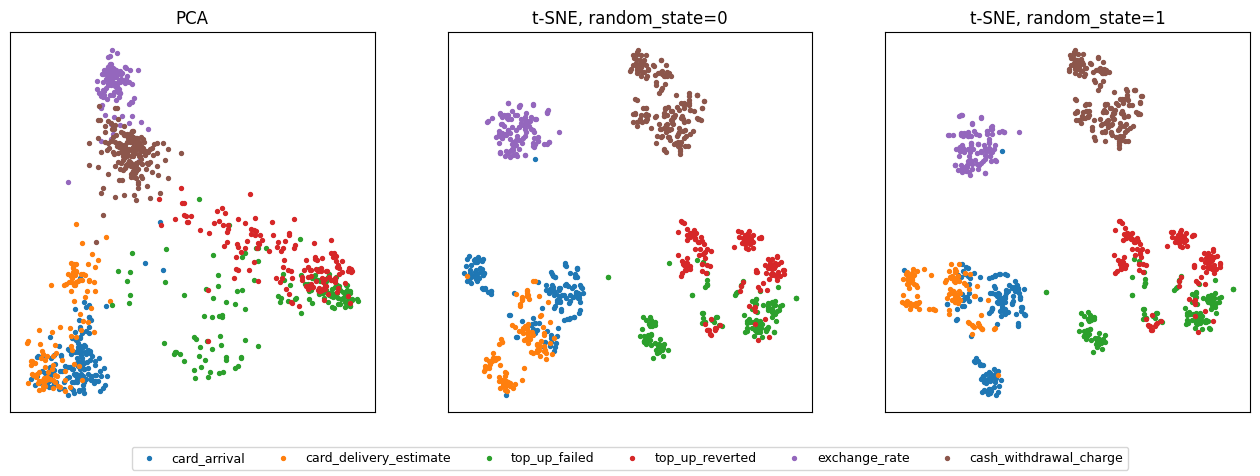

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
draw(pca_points, "PCA", axes[0])
draw(tsne_a, "t-SNE, random_state=0", axes[1])
draw(tsne_b, "t-SNE, random_state=1", axes[2])
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc="lower center", ncol=6, fontsize=9)
plt.subplots_adjust(bottom=0.12)
plt.show()

What the three pictures agree on:

- `exchange_rate` and `cash_withdrawal_charge` sit apart from the others: those questions are about different things.
- `card_arrival` and `card_delivery_estimate` overlap, and so do `top_up_failed` and `top_up_reverted`. Those are the near-twin intents. The embeddings put them together because their meanings really are close.

What the pictures disagree on: in the two t-SNE maps, the same data lands in different places, some intents break into several small islands in one map and not quite the same islands in the other, and the gaps between groups change size. None of that is information about the embeddings. It is how t-SNE happened to arrange things from a different starting point.

PCA draws the same overlaps more loosely. Neither picture is "the" embedding space. Both are flattened shadows of 384 dimensions.

### A number instead of a picture

Pictures can mislead, so here is a check that uses all 384 dimensions and no squashing. For every test question, look at its 10 nearest train questions and count how many share its intent. The average fraction is called **neighbourhood purity**. 1.0 would mean every neighbourhood is a single intent.

`np.argpartition(-block, 10, axis=1)[:, :10]` finds the 10 highest scores in each row without fully sorting them, which is faster than `argsort`.

In [47]:
def purity(test_matrix, train_matrix, k=10, chunk=500):
    fractions = []
    for start in range(0, test_matrix.shape[0], chunk):
        block = test_matrix[start:start + chunk] @ train_matrix.T
        block = block.toarray() if hasattr(block, "toarray") else block
        top = np.argpartition(-block, k, axis=1)[:, :k]
        same = y_train[top] == y_test[start:start + chunk, None]
        fractions.append(same.mean(axis=1))
    return np.concatenate(fractions).mean()

print(f"Neighbourhood purity (10 neighbours), TF-IDF: {purity(T_test, T_train):.4f}")
print(f"Neighbourhood purity (10 neighbours), MiniLM: {purity(E_test, E_train):.4f}")

Neighbourhood purity (10 neighbours), TF-IDF: 0.6280


Neighbourhood purity (10 neighbours), MiniLM: 0.8679


With MiniLM, on average **0.8679** of a test question's 10 nearest neighbours share its intent. With TF-IDF, **0.6280**. That says, with one number and no squashing, what the pictures only hinted at: MiniLM's neighbourhoods are much more organised by meaning.

> **Questions to sit with**
>
> 1. If two t-SNE runs of the same data look different, which features of the picture should you trust, and which should you ignore?
> 2. Why is neighbourhood purity a better thing to report in a write-up than a t-SNE picture?

## 12. Where embeddings fail

Embeddings are powerful, so it is important to know exactly where they let you down. We test three things.

### Word order and negation

We embed pairs of sentences and compare MiniLM's cosine similarity with TF-IDF's. Look at the numbers before reading on.

In [48]:
pairs = [
    ("the dog bit the man", "the man bit the dog"),
    ("I want to cancel my card", "I do not want to cancel my card"),
    ("my card was stolen", "someone took my card"),
    ("my card was stolen", "my card arrived today"),
]
rows = []
for s1, s2 in pairs:
    e = encoder.encode([s1, s2], normalize_embeddings=True, show_progress_bar=False)
    t = tfidf.transform([s1, s2])
    rows.append({"sentence 1": s1, "sentence 2": s2,
                 "MiniLM cosine": round(float(e[0] @ e[1]), 3),
                 "TF-IDF cosine": round(float((t[0] @ t[1].T).toarray()[0, 0]), 3)})
pd.DataFrame(rows)

,sentence 1,sentence 2,MiniLM cosine,TF-IDF cosine
0,the dog bit the man,the man bit the dog,0.979,1.000
1,I want to cancel my card,I do not want to cancel my card,0.967,0.871
2,my card was stolen,someone took my card,0.764,0.132
3,my card was stolen,my card arrived today,0.678,0.133


Read the table row by row.

1. **Word order.** "The dog bit the man" and "the man bit the dog" score **0.979** with MiniLM. The meanings are opposite, but the embedding barely notices. TF-IDF scores exactly **1.000**: it cannot see order at all. Mean pooling (Section 7) averages token vectors, and an average is a summary that loses a lot of order information.
2. **Negation.** "I want to cancel my card" and "I do not want to cancel my card" score **0.967**: *higher than the real paraphrase in row 3* (0.764). One word reverses the meaning, but almost all the other words are the same, so the vectors point almost the same way.
3. **Paraphrase.** Here MiniLM does what TF-IDF cannot. TF-IDF gives the paraphrase **0.132** and the unrelated pair (row 4) **0.133**: it cannot tell a paraphrase from an unrelated sentence, because neither shares meaningful words.

The lesson is not "embeddings are bad". It is: **embeddings measure overall topic and wording very well, and logic (not, before, after, who did what to whom) poorly.** Know which one your task needs.

### There is no universal "similar enough" number

People often want a rule like "a score above 0.7 means same meaning". Let us test that idea. We take 2,000 random pairs of train questions with the **same** intent and 2,000 random pairs with **different** intents, and look at their scores.

`np.random.default_rng(0)` makes a random number generator with a fixed seed (Day 4, note 4.2). `rng.integers(0, n, size)` draws random whole numbers from 0 up to `n − 1`.

In [49]:
rng = np.random.default_rng(0)
i = rng.integers(0, len(y_train), 200_000)
j = rng.integers(0, len(y_train), 200_000)
keep = i != j
i, j = i[keep], j[keep]
same = y_train[i] == y_train[j]
same_scores = np.sum(E_train[i[same][:2000]] * E_train[j[same][:2000]], axis=1)
diff_scores = np.sum(E_train[i[~same][:2000]] * E_train[j[~same][:2000]], axis=1)
print("Same-intent pairs:     ", len(same_scores), " median score", round(float(np.median(same_scores)), 3))
print("Different-intent pairs:", len(diff_scores), " median score", round(float(np.median(diff_scores)), 3))

Same-intent pairs:      2000  median score 0.599
Different-intent pairs: 2000  median score 0.193


We drew 200,000 random pairs because same-intent pairs are rare (with 77 intents, only about one random pair in 77 shares an intent) and we wanted at least 2,000 of them. `np.sum(A * B, axis=1)` takes the dot product of matching rows.

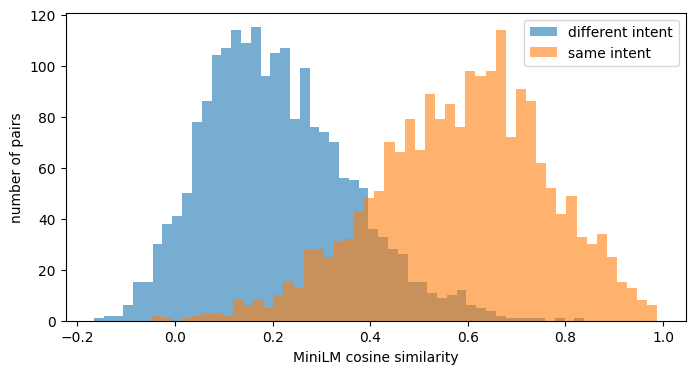

In [50]:
plt.figure(figsize=(8, 4))
plt.hist(diff_scores, bins=50, alpha=0.6, label="different intent")
plt.hist(same_scores, bins=50, alpha=0.6, label="same intent")
plt.xlabel("MiniLM cosine similarity")
plt.ylabel("number of pairs")
plt.legend()
plt.show()

In [51]:
for threshold in [0.5, 0.6, 0.7]:
    caught = (same_scores > threshold).mean()
    false = (diff_scores > threshold).mean()
    print(f"threshold {threshold}: same-intent pairs above it {caught:.3f}, different-intent pairs above it {false:.3f}")

threshold 0.5: same-intent pairs above it 0.696, different-intent pairs above it 0.037
threshold 0.6: same-intent pairs above it 0.497, different-intent pairs above it 0.011
threshold 0.7: same-intent pairs above it 0.271, different-intent pairs above it 0.003


The two piles overlap. Same-intent pairs have a median score of **0.599**, different-intent pairs **0.193**, but there is no clean gap between them.

Look at what each threshold does:

- At **0.7**, only **0.271** of same-intent pairs pass. You would miss most real matches.
- At **0.5**, **0.696** of same-intent pairs pass, but so do **0.037** of different-intent pairs.

0.037 sounds small. But in a real collection, almost every pair is a *different*-intent pair (76 out of every 77, here), so even a small false rate can produce more false matches than true ones.

And the numbers depend on the model, the data and the task. Another encoder puts its scores in a different range entirely. **The right threshold is something you measure on your own labelled examples, not a number you carry around.**

> **Questions to sit with**
>
> 1. A bank wants to route "I do not want to cancel my card" to a human and "I want to cancel my card" to an automatic cancel flow. Based on the table above, is MiniLM similarity alone safe for that? What would you add?
> 2. Your manager asks for "the similarity threshold for duplicates". What would you say, and what would you measure first?

### Where this goes next

What you built in Section 9, embed a query and find the most similar stored items, is the heart of a technique called **retrieval-augmented generation (RAG)**: before a language model answers a question, a similarity search finds the most relevant documents and hands them to it. Doing that search over millions of items quickly is the job of a **vector database**. Both belong to the Generative AI module. Today's lesson is the part they all rest on: the quality of the search is the quality of the embeddings, and you now know how to measure it.

## 13. What to take away

- An **embedding** is a learned representation: a fixed-length vector where similar meanings point in similar directions. This model gives 384 numbers per sentence.
- **RNNs, LSTMs and GRUs** read text one word at a time through a running summary. They forget over long texts and cannot run in parallel. **Attention** (Day 6) replaced them.
- **TF-IDF** is a hand-made text representation. It is fast, but it cannot see word order and cannot link different words with the same meaning.
- **Cosine similarity** measures direction and ignores length. For **unit vectors**, cosine is just the dot product, which makes search one matrix multiplication.
- Inside the encoder: **tokenizer → Transformer (one vector per token) → mean pooling → normalise.** We rebuilt it by hand and matched `encode`.
- Scored fairly, on the same test questions with a sign test, MiniLM embeddings beat TF-IDF clearly at nearest-neighbour search.
- **Pictures of embedding spaces mislead.** Trust numbers like neighbourhood purity over t-SNE shapes.
- Embeddings **miss negation and word order**, struggle with **slang and rare words**, and there is **no universal threshold**. Measure on your own data before trusting a score.
- Defaults can mislead: logistic regression on embeddings needed weaker regularisation, chosen on **validation** data, to beat 1-NN.

### Next: note 5.3 — Learning without labels

MiniLM was trained on a huge amount of text, but nobody hand-labelled that text with 77 bank intents. So how did it learn that "stolen" and "took" belong together? In note 5.3 you will train a small encoder **with no labels at all**, using a trick called contrastive learning, and measure honestly what it learned.